In [1]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("dark_background")

from src.models.train import (
    LogisticRegressionModel,
    RandomForestModel,
    LinearSVCModel,
    NOTAMTrainer,
)
from src.models.evaluate import (
    plot_model_comparison,
    plot_confusion_matrices,
    plot_per_class_f1,
    plot_learning_curve,
)

print("✅ Imports OK")

✅ Imports OK


In [2]:
splits = joblib.load("../data/processed/train_test_splits.pkl")

X_train   = splits["X_train"]
X_test    = splits["X_test"]
y_train   = splits["y_train"]
y_test    = splits["y_test"]
classes   = list(splits["classes"])

print(f"X_train : {X_train.shape} | X_test : {X_test.shape}")
print(f"Classes : {classes}")

X_train : (1047, 275) | X_test : (262, 275)
Classes : ['AERODROME_PROCEDURE', 'AIRSPACE_RESTRICTION', 'LIGHTING', 'NAVIGATION_AID', 'OBSTACLE', 'RUNWAY_CLOSURE']


In [3]:
trainer = NOTAMTrainer(cv_folds=5)

# Modèle 1
lr_result  = trainer.train_and_evaluate(
    LogisticRegressionModel(C=5.0),
    X_train, y_train, X_test, y_test, classes
)

# Modèle 2
rf_result  = trainer.train_and_evaluate(
    RandomForestModel(n_estimators=200),
    X_train, y_train, X_test, y_test, classes
)

# Modèle 3
svc_result = trainer.train_and_evaluate(
    LinearSVCModel(C=1.0),
    X_train, y_train, X_test, y_test, classes
)

print("\n" + "="*55)
print("  📋 TABLEAU COMPARATIF FINAL")
print("="*55)
print(trainer.comparison_dataframe().to_string(index=False))


  🚀 Training : Logistic Regression
  ⚙️  5-fold Stratified CV...
  CV F1-macro : 0.9891 ± 0.0138
  📚 Final fit on full train set...
  ✅ Done in 0.26s
┌─ Logistic Regression            ──────────────────────────┐
│  CV  F1-macro  : 0.9891 ± 0.0138          │
│  Test F1-macro : 0.9883                          │
│  Test Accuracy : 0.9962                          │
│  Train time    : 0.26s                           │
└──────────────────────────────────────────────────┘
  💾 Model saved → data\processed\models\Logistic_Regression.pkl

  🚀 Training : Random Forest
  ⚙️  5-fold Stratified CV...
  CV F1-macro : 0.9875 ± 0.0138
  📚 Final fit on full train set...
   [RF] OOB Score : 0.9933
  ✅ Done in 0.56s
┌─ Random Forest                  ──────────────────────────┐
│  CV  F1-macro  : 0.9875 ± 0.0138          │
│  Test F1-macro : 0.9883                          │
│  Test Accuracy : 0.9962                          │
│  Train time    : 0.56s                           │
└─────────────────────────

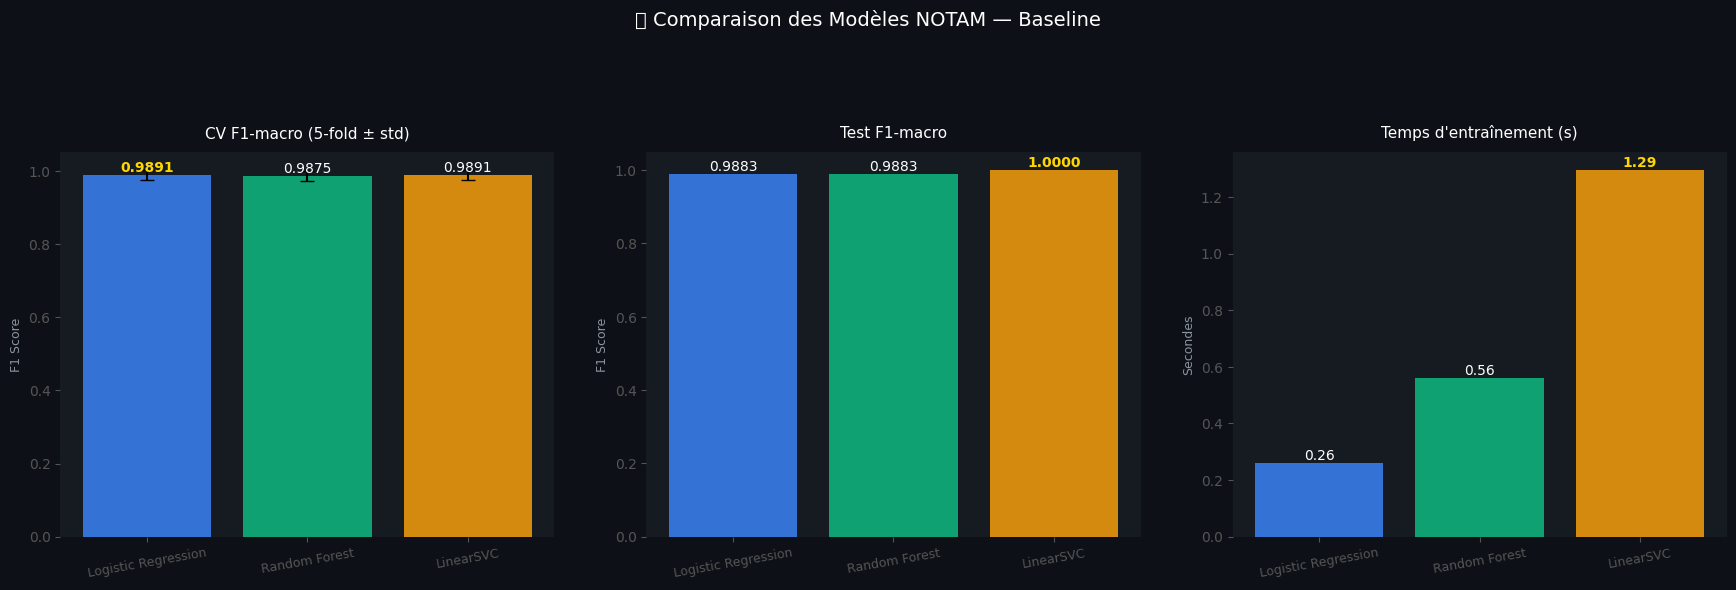

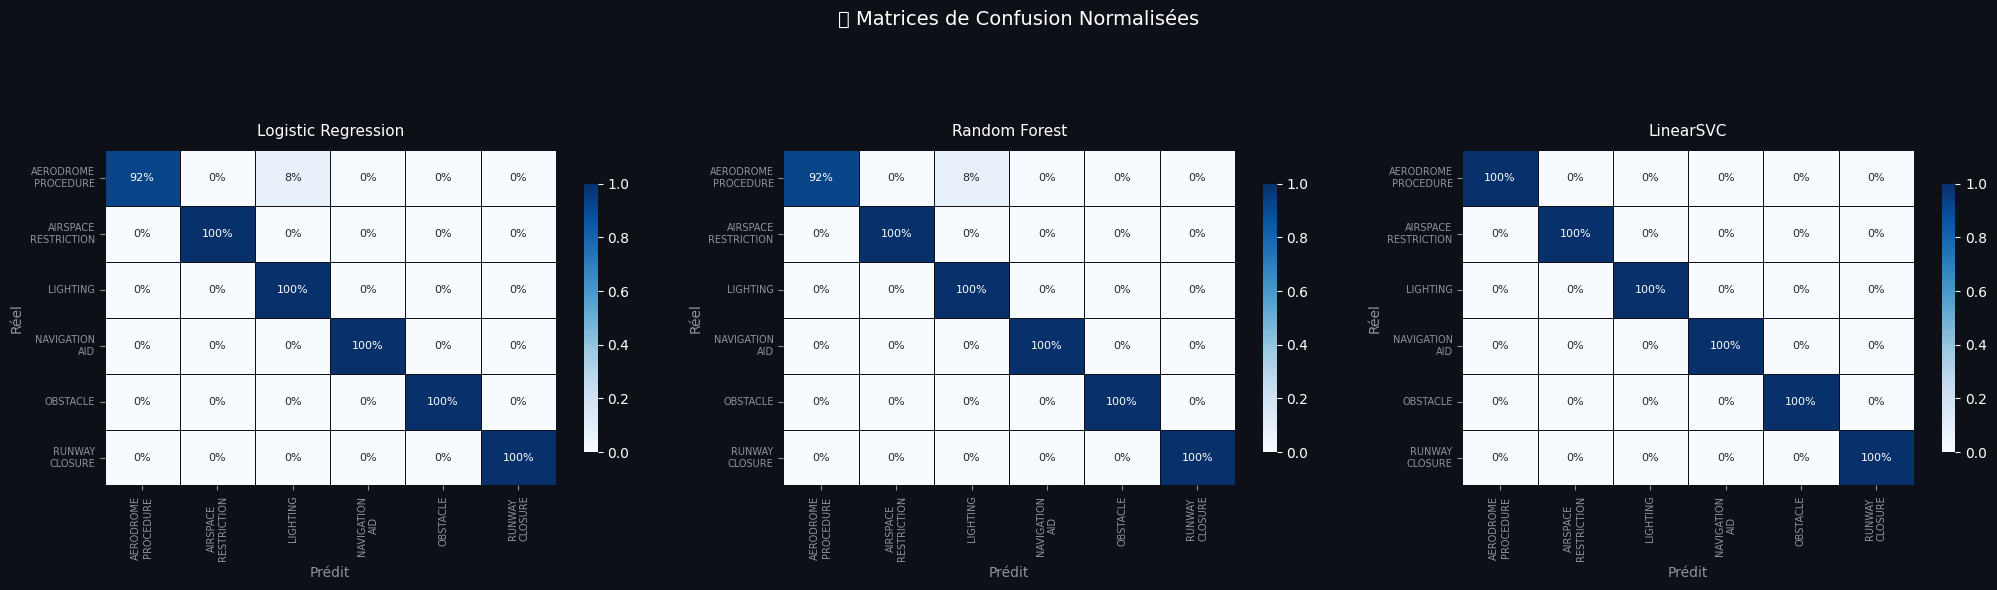

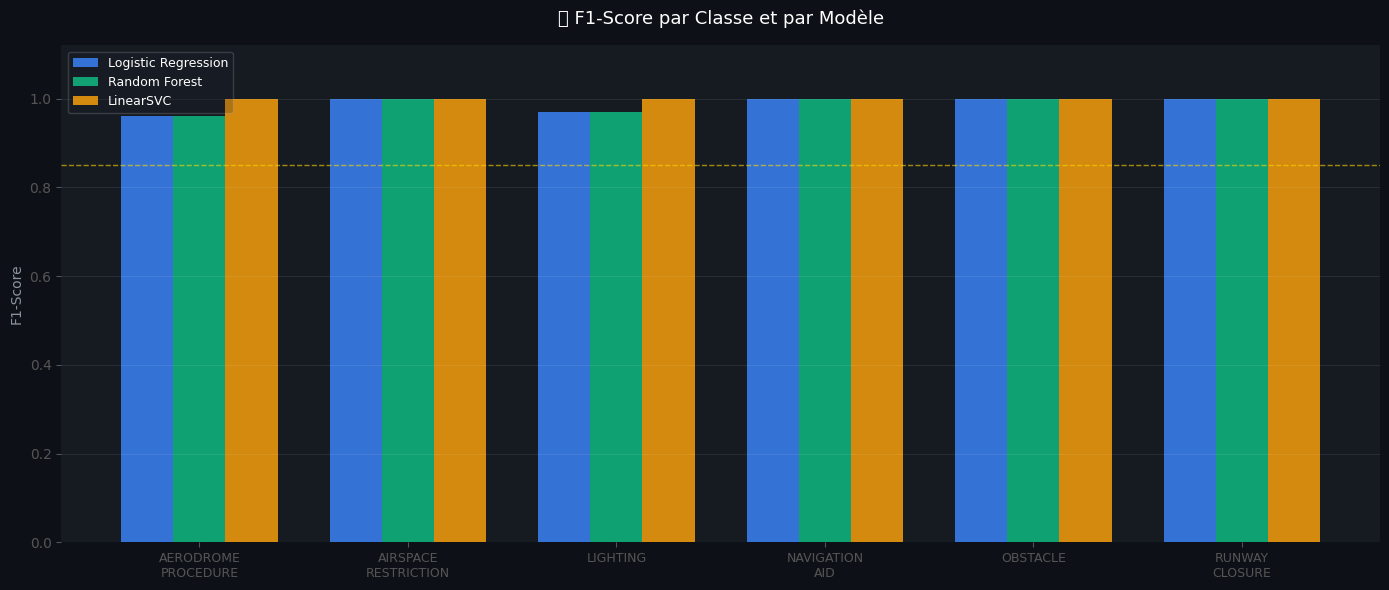

In [4]:
results = [lr_result, rf_result, svc_result]

plot_model_comparison(
    results,
    save_path="../data/processed/fig_09_model_comparison.png"
)

plot_confusion_matrices(
    results, classes,
    save_path="../data/processed/fig_10_confusion_matrices.png"
)

plot_per_class_f1(
    results, classes,
    save_path="../data/processed/fig_11_per_class_f1.png"
)

🏆 Meilleur modèle : LinearSVC (Calibrated) (F1=1.0000)


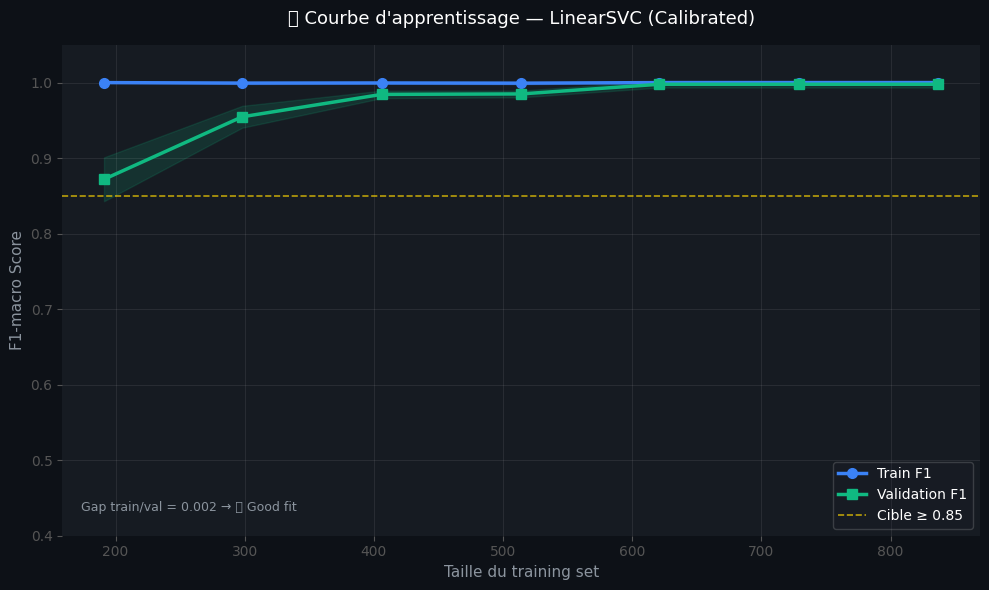

In [5]:
best = trainer.get_best()
print(f"🏆 Meilleur modèle : {best.model_name} (F1={best.test_f1_macro:.4f})")

plot_learning_curve(
    best.model, X_train, y_train,
    model_name=best.model_name,
    save_path="../data/processed/fig_12_learning_curve.png"
)

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
import time

print("🔍 GridSearchCV sur LinearSVC (meilleur modèle)...")
print("   Paramètres explorés : C ∈ {0.01, 0.1, 1, 5, 10}")
print("   Stratégie : 5-fold Stratified CV, scoring=f1_macro\n")

param_grid = {"estimator__C": [0.01, 0.1, 1.0, 5.0, 10.0]}

base_svc = CalibratedClassifierCV(
    estimator=LinearSVC(
        multi_class="crammer_singer",
        max_iter=2000,
        random_state=42,
        class_weight="balanced",
    ),
    cv=3, method="sigmoid",
)

grid_search = GridSearchCV(
    estimator=base_svc,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
    refit=True,
)

t0 = time.time()
grid_search.fit(X_train, y_train)
elapsed = time.time() - t0

print(f"\n✅ GridSearch terminé en {elapsed:.1f}s")
print(f"   Meilleur C        : {grid_search.best_params_}")
print(f"   Meilleur CV F1    : {grid_search.best_score_:.4f}")

# Évaluation du modèle tuné
from sklearn.metrics import f1_score, accuracy_score, classification_report

y_pred_tuned = grid_search.best_estimator_.predict(X_test)
f1_tuned     = f1_score(y_test, y_pred_tuned, average="macro")
acc_tuned    = accuracy_score(y_test, y_pred_tuned)

print(f"\n📊 Modèle TUNÉ — Résultats Test :")
print(f"   F1-macro  : {f1_tuned:.4f}  (avant tuning : {svc_result.test_f1_macro:.4f})")
print(f"   Accuracy  : {acc_tuned:.4f}")
print(f"\n{classification_report(y_test, y_pred_tuned, target_names=classes)}")

🔍 GridSearchCV sur LinearSVC (meilleur modèle)...
   Paramètres explorés : C ∈ {0.01, 0.1, 1, 5, 10}
   Stratégie : 5-fold Stratified CV, scoring=f1_macro

Fitting 5 folds for each of 5 candidates, totalling 25 fits

✅ GridSearch terminé en 7.0s
   Meilleur C        : {'estimator__C': 1.0}
   Meilleur CV F1    : 0.9978

📊 Modèle TUNÉ — Résultats Test :
   F1-macro  : 1.0000  (avant tuning : 1.0000)
   Accuracy  : 1.0000

                      precision    recall  f1-score   support

 AERODROME_PROCEDURE       1.00      1.00      1.00        13
AIRSPACE_RESTRICTION       1.00      1.00      1.00        62
            LIGHTING       1.00      1.00      1.00        16
      NAVIGATION_AID       1.00      1.00      1.00        47
            OBSTACLE       1.00      1.00      1.00        80
      RUNWAY_CLOSURE       1.00      1.00      1.00        44

            accuracy                           1.00       262
           macro avg       1.00      1.00      1.00       262
        weighte

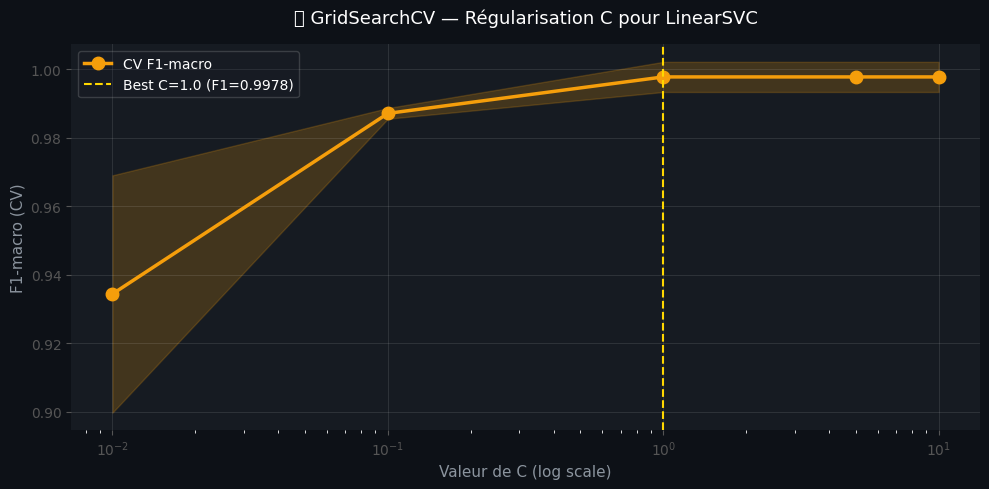


💾 Meilleur modèle sauvegardé → data/processed/models/best_model.pkl
   Paramètres : {'estimator__C': 1.0}
   F1-macro test : 1.0000


In [7]:
# ── Graphique GridSearch ──────────────────────────────────────────────────────
cv_results = pd.DataFrame(grid_search.cv_results_)
c_values   = [p["estimator__C"] for p in cv_results["params"]]
mean_scores= cv_results["mean_test_score"].values
std_scores = cv_results["std_test_score"].values

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#161b22")
ax.semilogx(c_values, mean_scores, "o-", color="#f59e0b",
            linewidth=2.5, markersize=9, label="CV F1-macro")
ax.fill_between(c_values, mean_scores - std_scores,
                mean_scores + std_scores, alpha=0.2, color="#f59e0b")
best_c = grid_search.best_params_["estimator__C"]
best_s = grid_search.best_score_
ax.axvline(best_c, color="gold", linestyle="--", linewidth=1.5,
           label=f"Best C={best_c} (F1={best_s:.4f})")
ax.set_xlabel("Valeur de C (log scale)", color="#8b949e", fontsize=11)
ax.set_ylabel("F1-macro (CV)", color="#8b949e", fontsize=11)
ax.set_title("🔧 GridSearchCV — Régularisation C pour LinearSVC",
             color="white", fontsize=13, pad=15)
ax.legend(fontsize=10, framealpha=0.2, labelcolor="white", facecolor="#1c1c2c")
ax.spines[:].set_visible(False); ax.tick_params(colors="#555")
ax.grid(alpha=0.1)
plt.tight_layout()
plt.savefig("../data/processed/fig_13_gridsearch.png", dpi=150,
            bbox_inches="tight", facecolor="#0d1117")
plt.show()

# ── Sauvegarde du modèle final ────────────────────────────────────────────────
final_model = grid_search.best_estimator_
joblib.dump(final_model, "../data/processed/models/best_model.pkl")
print(f"\n💾 Meilleur modèle sauvegardé → data/processed/models/best_model.pkl")
print(f"   Paramètres : {grid_search.best_params_}")
print(f"   F1-macro test : {f1_tuned:.4f}")